# 03_How_The_Algorithm_Works.ipynb — Polynomial Regression

---

# Step-by-Step Workflow

Unlike Ridge or Lasso, Polynomial Regression has **two stages**:

```text
Original Features
        ↓
Generate Polynomial Features
        ↓
Train Linear Regression
        ↓
Learn Coefficients
        ↓
Predict
```

Notice something important:

> **Polynomial Regression itself does not learn anything.**

It only **creates new features**.

The actual learning is done by **Linear Regression**.

---

# Complete Workflow

Suppose we have this dataset:

| House Size | Price |
| ---------- | ----- |
| 1          | 2     |
| 2          | 5     |
| 3          | 10    |
| 4          | 17    |
| 5          | 26    |

The relationship is approximately

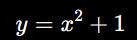

A straight line cannot fit this well.

---

## Step 1 — Collect Data

Original dataset

| x | y  |
| - | -- |
| 1 | 2  |
| 2 | 5  |
| 3 | 10 |
| 4 | 17 |
| 5 | 26 |

Only one feature exists.

```text
x
```

---

## Step 2 — Choose Polynomial Degree

Suppose

```python
degree = 2
```

This tells `PolynomialFeatures`

> "Generate all polynomial terms up to power 2."

---

## Step 3 — Create New Features

Original

| x |
| - |
| 1 |
| 2 |
| 3 |
| 4 |
| 5 |

becomes

| x | x² |
| - | -- |
| 1 | 1  |
| 2 | 4  |
| 3 | 9  |
| 4 | 16 |
| 5 | 25 |

If `include_bias=True` (default)

it actually becomes

| 1 | x | x² |
| - | - | -- |
| 1 | 1 | 1  |
| 1 | 2 | 4  |
| 1 | 3 | 9  |
| 1 | 4 | 16 |
| 1 | 5 | 25 |

---

## Step 4 — Train Linear Regression

Now Linear Regression receives

```text
Feature 1 → x

Feature 2 → x²
```

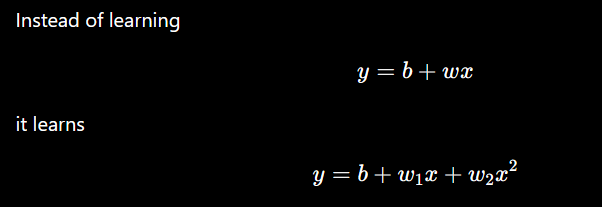

The training algorithm is **exactly the same** as ordinary Linear Regression.

---

## Step 5 — Learn Coefficients

Suppose after training

the model learns

```text
Intercept = 1

Coefficient of x = 0

Coefficient of x² = 1
```

The learned equation becomes

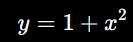

---

## Step 6 — Prediction

Suppose

```text
x = 6
```

PolynomialFeatures first converts it into

```text
6

36
```

Then Linear Regression computes

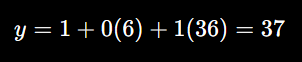

Prediction

```text
37
```

Notice

The model never directly predicts from

```text
6
```

It predicts from

```text
6

36
```

---

# Training Process

Let's see what happens internally.

---

## Stage 1

Input

```text
Original Features
```

↓

PolynomialFeatures

↓

Expanded Features

---

## Stage 2

Expanded Features

↓

Linear Regression

↓

Find Best Coefficients

---

The training process is

```text
Training Data

↓

PolynomialFeatures

↓

New Matrix

↓

Linear Regression

↓

Optimal Coefficients
```

---

## Internal View

Suppose

Original feature

```text
Age
```

Training matrix

```text
20

30

40
```

After transformation

```text
Age

Age²
```

becomes

```text
20     400

30     900

40    1600
```

Linear Regression trains using these values.

---

# Prediction Process

Prediction follows the **same transformation**.

Suppose new sample

```text
Age = 50
```

The model does **not** directly compute prediction.

Instead

Step 1

Generate

```text
50

2500
```

Step 2

Apply Linear Regression equation

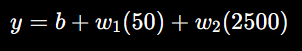

Step 3

Return prediction.

---

# Flow Diagram

```text
                 TRAINING

Original Dataset
        │
        ▼
Polynomial Feature Generation
        │
        ▼
Expanded Dataset
        │
        ▼
Linear Regression Training
        │
        ▼
Learn Coefficients
        │
        ▼
Save Model
```

---

Prediction

```text
New Sample
     │
     ▼
Polynomial Feature Generation
     │
     ▼
Expanded Sample
     │
     ▼
Linear Regression Equation
     │
     ▼
Prediction
```

---

# Small Numerical Example

Let's manually perform Polynomial Regression.

---

## Original Data

| x | y  |
| - | -- |
| 1 | 3  |
| 2 | 7  |
| 3 | 13 |

Notice

These values follow

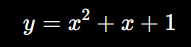

---

## Step 1

Original matrix

```text
1

2

3
```

---

## Step 2

Degree = 2

Create

| x | x² |
| - | -- |
| 1 | 1  |
| 2 | 4  |
| 3 | 9  |

---

## Step 3

Linear Regression now solves

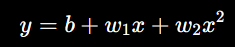

Suppose it learns

```text
b = 1

w₁ = 1

w₂ = 1
```

Equation

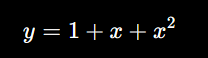

---

## Step 4

Predict

Suppose

```text
x = 4
```

Transform

```text
4

16
```

Prediction

[
1+4+16=21
]

Exactly matches

the original function.

---

# Visualization of Working

## Original Data

```text
Feature

x
```

↓

---

## PolynomialFeatures

```text
x

x²
```

↓

---

## Linear Regression

Learns

```text
Intercept

Weight of x

Weight of x²
```

↓

---

## Final Equation

```text
Prediction
```

↓

Curved Graph

---

## Another Example

Original Features

```text
Height

Weight
```

Degree = 2

Generated Features

```text
Height

Weight

Height²

Height × Weight

Weight²
```

Then Linear Regression learns one coefficient for each generated feature.

---

# Algorithm Summary

### Input

* Original numerical features
* Polynomial degree

↓

### Feature Engineering

Generate polynomial and interaction features up to the chosen degree.

↓

### Learning

Train a standard Linear Regression model on the expanded feature matrix.

↓

### Prediction

For every new sample:

1. Generate the same polynomial features.
2. Apply the learned Linear Regression equation.
3. Return the predicted value.

---

# Key Takeaways

* **Polynomial Regression is a preprocessing technique plus Linear Regression.**
* It **does not replace Linear Regression**; it expands the feature space before fitting the model.
* The **degree** controls model complexity:

  * Degree 1 → Linear Regression
  * Degree 2 → Quadratic relationship
  * Degree 3 → Cubic relationship
  * Higher degrees → More flexible, but greater risk of overfitting
* **Training and prediction both require the same polynomial transformation.** This is why `Pipeline` is the recommended approach in scikit-learn.

---